In [ ]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an
FONTSIZE = 16


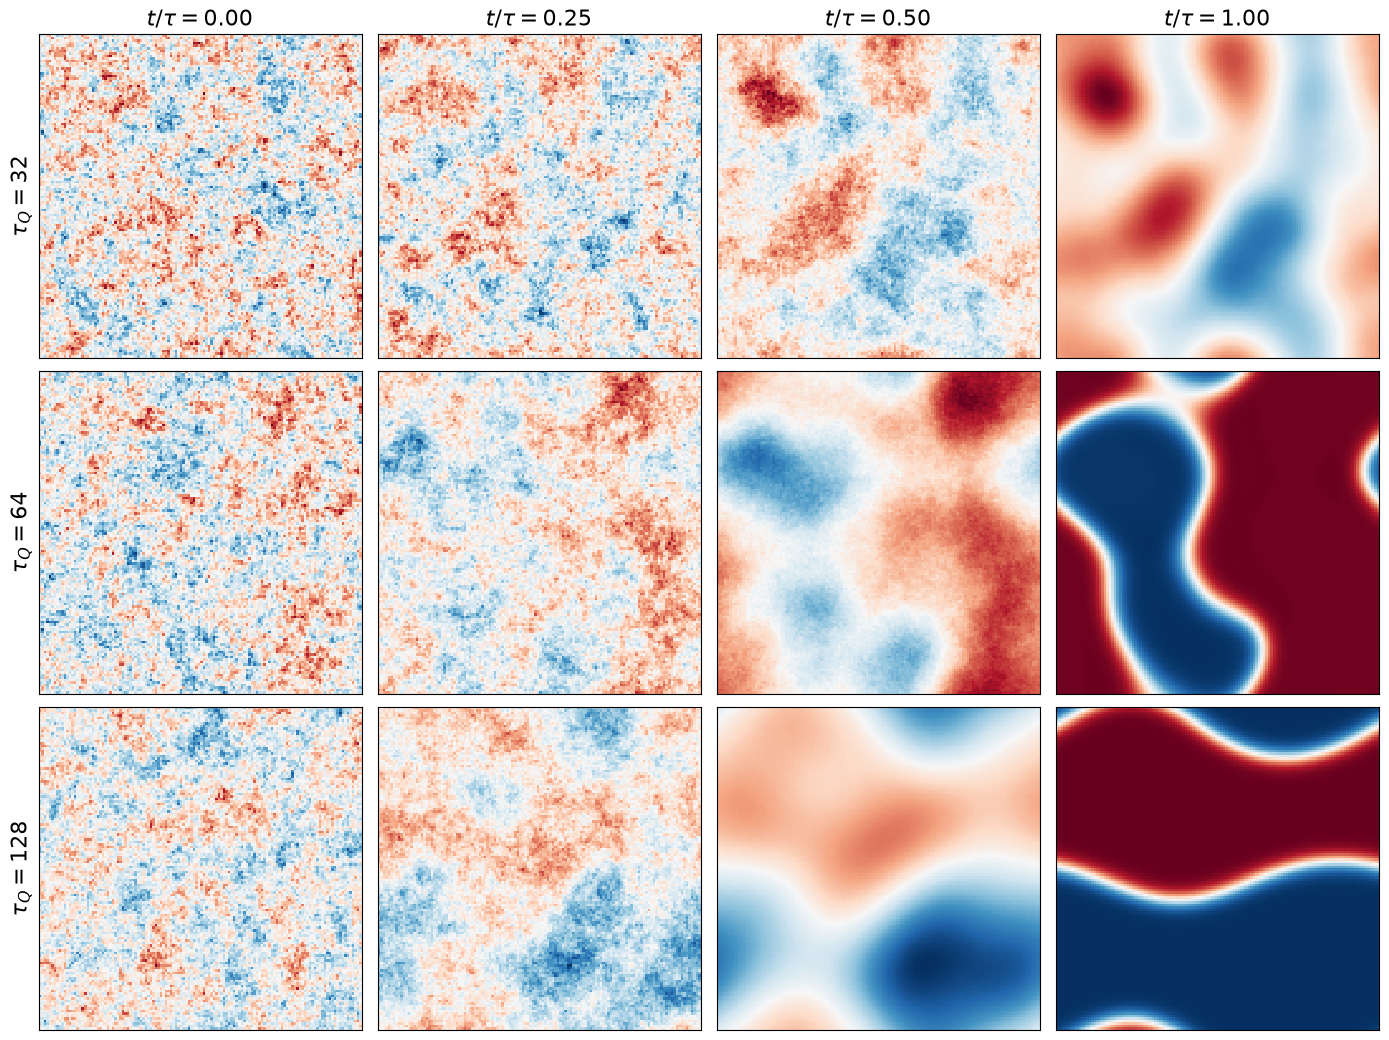

In [16]:
# ---- inputs ----
TAUS     = [32, 64, 128]
T_FRACS  = [0.0, 0.25, 0.5, 1.0]    # times to show, in units of tau (1.0 = end of quench)
SAMPLE   = 0
FONTSIZE = 16

fig, axes = plt.subplots(len(TAUS), len(T_FRACS),
                         figsize=(3.5 * len(T_FRACS), 3.5 * len(TAUS)), squeeze=False)

for row, tau in enumerate(TAUS):
    d = an.load_chunk(tau)
    for col, frac in enumerate(T_FRACS):
        snaps_t, t_used = an.snapshot_at(d, frac * tau)   # nearest stored time, all samples
        f = snaps_t[SAMPLE]
        v = np.abs(f).max()                               # per-panel symmetric scale
        ax = axes[row, col]
        ax.imshow(f, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(rf"$t/\tau = {t_used / tau:.2f}$", fontsize=FONTSIZE)
        if col == 0:
            ax.set_ylabel(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)

plt.tight_layout()
#plt.savefig("../figures/2d/evolution_vs_tau.png", dpi=150)
plt.show()